# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [2]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 10.1 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [5]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [6]:
# Uncomment and run the following code in case Google Colab is being used
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from google.colab import files
from pathlib import Path

#load the images
images = np.load('/content/drive/MyDrive/Helmet/images.npy')
#load the labels
labels = pd.read_csv('/content/drive/MyDrive/Helmet/labels.csv')

print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


There are 4125 RGB images of shape 200 x 200, each image having 3 channels.

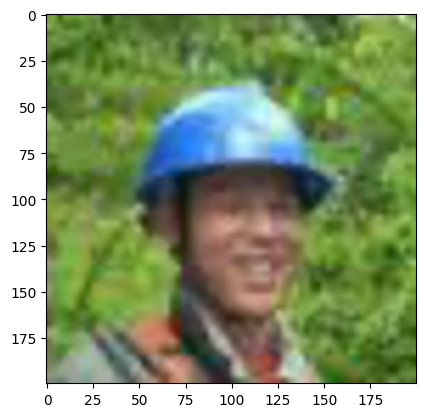

In [8]:
plt.imshow(images[3444]);

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

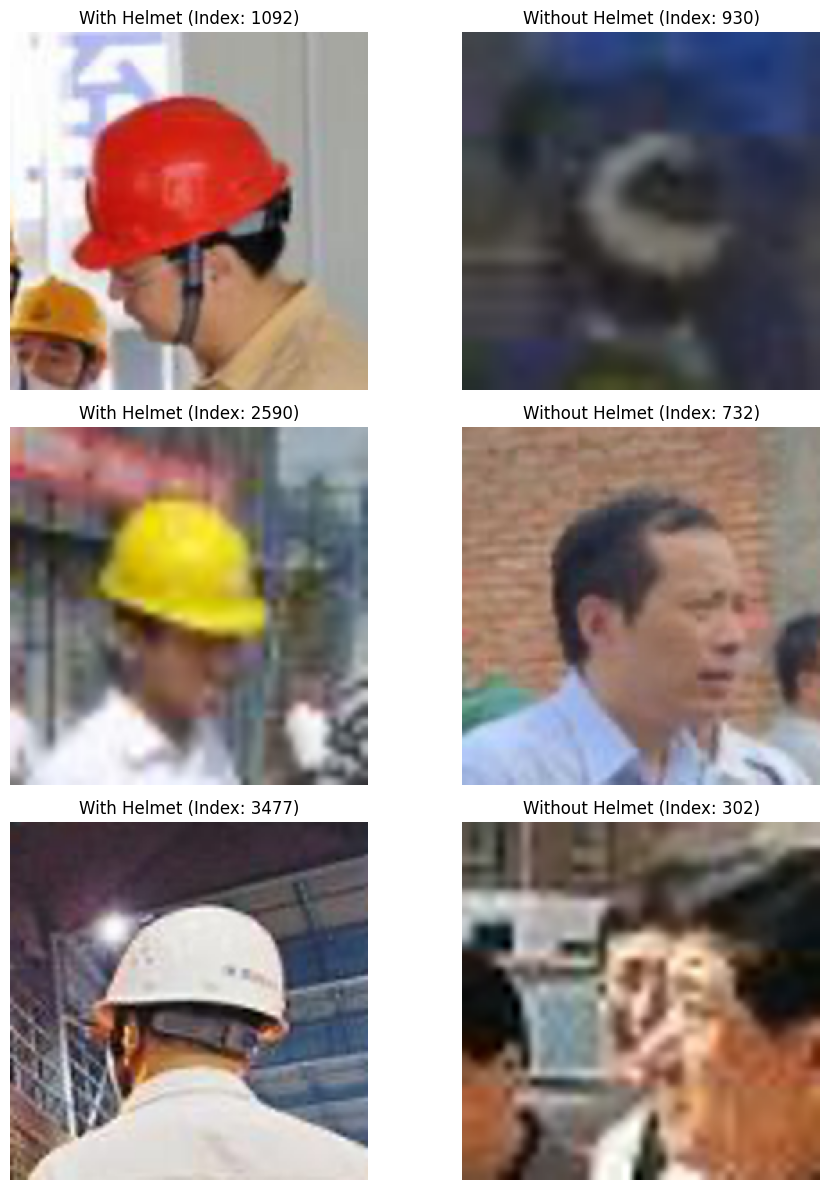

In [9]:
# Get indices for 'With Helmet' (label 1) and 'Without Helmet' (label 0)
helmet_indices = labels[labels.iloc[:, 0] == 1].index.tolist()
no_helmet_indices = labels[labels.iloc[:, 0] == 0].index.tolist()

# Select 5 random indices from each class
num_samples_to_plot = 3
random_helmet_idxs = random.sample(helmet_indices, num_samples_to_plot)
random_no_helmet_idxs = random.sample(no_helmet_indices, num_samples_to_plot)

fig, axes = plt.subplots(num_samples_to_plot, 2, figsize=(10, 4 * num_samples_to_plot))

for i in range(num_samples_to_plot):
    # Plot 'With Helmet' images
    axes[i][0].imshow(images[random_helmet_idxs[i]])
    axes[i][0].set_title(f"With Helmet (Index: {random_helmet_idxs[i]})")
    axes[i][0].axis("off")

    # Plot 'Without Helmet' images
    axes[i][1].imshow(images[random_no_helmet_idxs[i]])
    axes[i][1].set_title(f"Without Helmet (Index: {random_no_helmet_idxs[i]})")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

## Checking for class imbalance


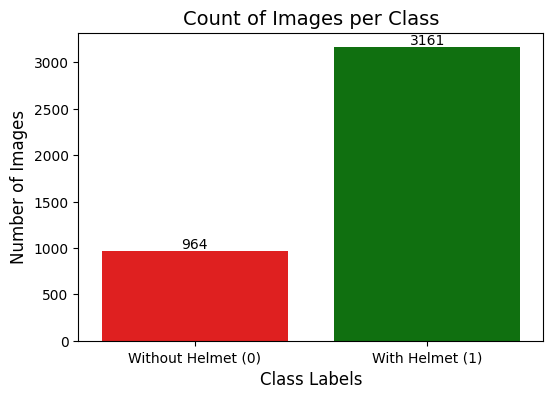

In [10]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

# **Data Preprocessing**

### Splitting the dataset





*   As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
*   We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.



In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels) #Complete the code to define the test_size
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp) #Complete the code to define the test_size

In [12]:
#print the shape of the train data
print(X_train.shape,y_train.shape)
#print the shape of the Val data
print(X_val.shape,y_val.shape)
#print the shape of the Test data
print(X_test.shape,y_test.shape)

(3300, 200, 200, 3) (3300, 1)
(412, 200, 200, 3) (412, 1)
(413, 200, 200, 3) (413, 1)


### Data Normalization

Since the image pixel values range from **0-255**, our method of normalization here will be **scaling** - we shall divide all the pixel values by 255 to standardize the images to have values between 0-1.

In [13]:
X_train_normalized = X_train.astype('float32')/255.0 #normalize the training images
X_val_normalized = X_val.astype('float32')/255.0  #normalize the validation images
X_test_normalized = X_test.astype('float32')/255.0   #normalize the test images

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [14]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [15]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [17]:
# Initializing Model
model_CNN = Sequential()

# Convolutional layers
# 1. Input shape: (height, width, channels).
model_CNN.add(Conv2D(16, (3, 3), activation='relu', padding="same", input_shape=(200, 200, 3)))
model_CNN.add(MaxPooling2D((4, 4), padding='same'))

# 2. Second Conv layer: Double the filters (32), keep standard (3,3) kernel and 'relu'
model_CNN.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
# Standard pooling kernel is usually (2, 2)
model_CNN.add(MaxPooling2D((2, 2), padding='same'))

# 3. Third Conv layer: Double the filters again (64), keep (3,3) kernel and 'relu'
model_CNN.add(Conv2D(64, (3, 3), activation='relu', padding="same"))

# Flatten and Dense layers
model_CNN.add(Flatten())
model_CNN.add(Dense(4, activation='relu'))

# Output layer: 4 neurons (matching your classification categories)
# with 'softmax' for multi-class probability distribution
model_CNN.add(Dense(1, activation='sigmoid'))


# Compile model
model_CNN.compile(optimizer= 'adam', loss='binary_crossentropy', metrics=['accuracy'])
# Generating the summary of the model
model_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       160,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,593 (717.16 KB)

 Trainable params: 183,593 (717.16 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_CNN = model_CNN.fit(
    X_train_normalized, y_train,
    epochs=20,
    validation_data=(X_val_normalized, y_val),
    batch_size=64,
    shuffle=True,
    verbose=2
)

Epoch 1/20
52/52 - 8s - 147ms/step - accuracy: 0.7630 - loss: 0.4764 - val_accuracy: 0.7670 - val_loss: 0.3115
Epoch 2/20
52/52 - 2s - 43ms/step - accuracy: 0.8688 - loss: 0.3009 - val_accuracy: 0.9175 - val_loss: 0.2471
Epoch 3/20
52/52 - 2s - 47ms/step - accuracy: 0.9079 - loss: 0.2695 - val_accuracy: 0.9296 - val_loss: 0.2355
Epoch 4/20
52/52 - 3s - 49ms/step - accuracy: 0.9155 - loss: 0.2551 - val_accuracy: 0.9248 - val_loss: 0.2296
Epoch 5/20
52/52 - 2s - 45ms/step - accuracy: 0.9236 - loss: 0.2453 - val_accuracy: 0.9442 - val_loss: 0.2285
Epoch 6/20
52/52 - 2s - 47ms/step - accuracy: 0.9270 - loss: 0.2356 - val_accuracy: 0.9272 - val_loss: 0.2253
Epoch 7/20
52/52 - 2s - 47ms/step - accuracy: 0.9273 - loss: 0.2332 - val_accuracy: 0.9296 - val_loss: 0.2284
Epoch 8/20
52/52 - 2s - 47ms/step - accuracy: 0.9333 - loss: 0.2229 - val_accuracy: 0.9466 - val_loss: 0.2279
Epoch 9/20
52/52 - 3s - 56ms/step - accuracy: 0.9373 - loss: 0.2136 - val_accuracy: 0.9417 - val_loss: 0.2174
Epoch 10/

**Findings**


*   Our data had 183,593 trainable parameters.
*   After running 20 epochs, we were able to acheive a training accuracy of ~96% and testing accuracy of ~93
*   The model performs decently with both training and testing data and doesn't seem to overfit as the accuracy difference between training and test data sets is just 3% points




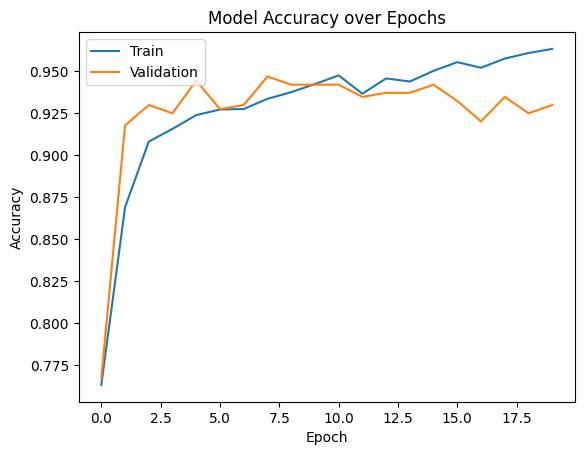

In [20]:
plt.plot(history_CNN.history['accuracy'])
plt.plot(history_CNN.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Findings**
*  2-5 epochs seems to be the sweetspot for both validation and training datasets
*  More than 15 epochs training dataset seems to overfit

In [21]:
model_CNN_train_perf = model_performance_classification(model_CNN, X_train_normalized,y_train)

print("Train performance metrics")
print(model_CNN_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.960303  0.960303   0.960303  0.960303


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


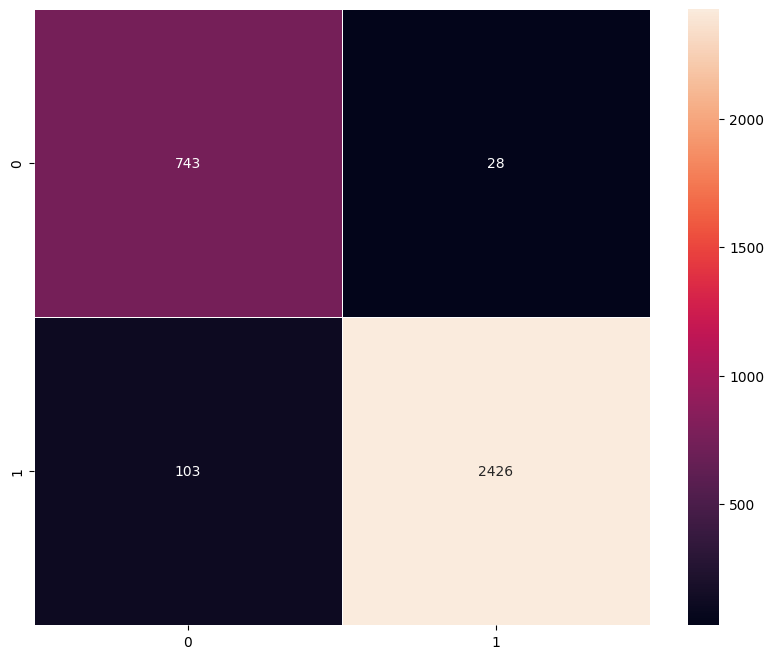

In [22]:
plot_confusion_matrix(model_CNN,X_train_normalized,y_train)

In [23]:
model_CNN_valid_perf = model_performance_classification(model_CNN, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_CNN_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.929612  0.929612   0.929612  0.929612


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


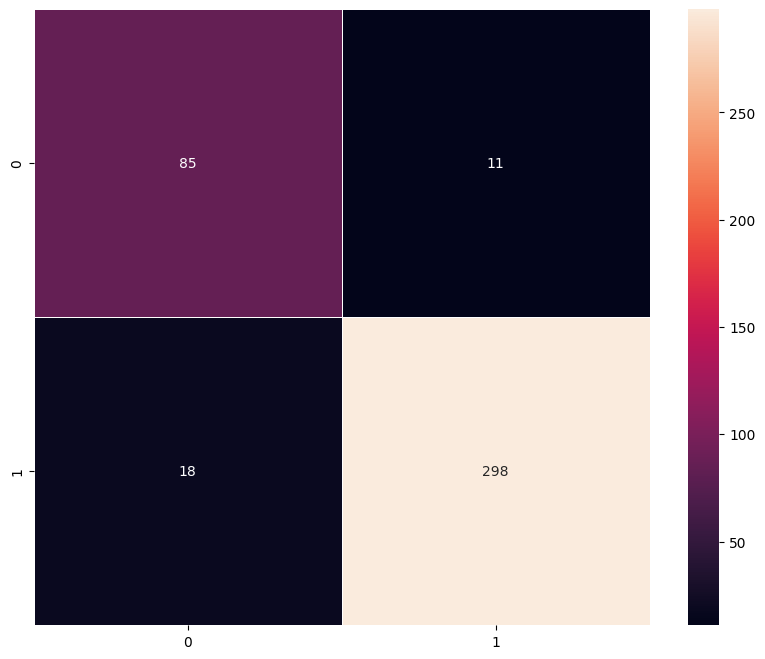

In [24]:
plot_confusion_matrix(model_CNN,X_val_normalized,y_val)

**Findings**

* The model was pretty accurate in predicting both training and testing datasets

### Visualizing the predictions

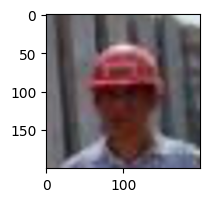

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label: 1
True Label: label    1
Name: 4098, dtype: int64


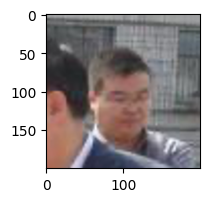

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Label: 1
True Label: label    0
Name: 719, dtype: int64


In [29]:
# For index 67
plt.figure(figsize=(2,2))
plt.imshow(X_val[67])
plt.show()
prediction = model_CNN.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[67]
print('True Label:', true_label)

# For index 76
plt.figure(figsize=(2,2))
plt.imshow(X_val[76])
plt.show()
prediction = model_CNN.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[76]
print('True Label:', true_label)

**Findings**



*   In the first example it was able to accurately predit
*   In the second example it failed to predict accurately, it could be due to limited number of images the model trained on



## Model 2: Transfer Learning with VGG-16 (Base)

For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.

In [30]:
model_VGG = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
model_VGG.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in model_VGG.layers:
    layer.trainable = False

In [33]:
model_1 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_1.add(model_VGG)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_1.add(Flatten())

# Adding a dense output layer
model_1.add(Dense(1, activation='sigmoid'))

In [34]:
# Compile model
model_1.compile(optimizer= 'adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
# Generating the summary of the model
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [36]:
train_datagen = ImageDataGenerator()

In [37]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_vgg16 = model_1.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 865ms/step - accuracy: 0.7516 - loss: 0.5415 - val_accuracy: 0.8010 - val_loss: 0.3779
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6875 - loss: 0.5105 - val_accuracy: 0.8034 - val_loss: 0.3785
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 727ms/step - accuracy: 0.8629 - loss: 0.3255 - val_accuracy: 0.8714 - val_loss: 0.3052
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8906 - loss: 0.2869 - val_accuracy: 0.8495 - val_loss: 0.3158
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 770ms/step - accuracy: 0.8799 - loss: 0.2820 - val_accuracy: 0.8665 - val_loss: 0.2857
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8984 - loss: 0.2282 - val_accuracy: 0.8665 - val_loss: 0.2887
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 733ms/step - accuracy: 0.9072 - loss: 0.2424 - val_accuracy: 0.8738 - val_loss: 0.2639
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8700 - loss: 0.3018 - val_accuracy: 0.

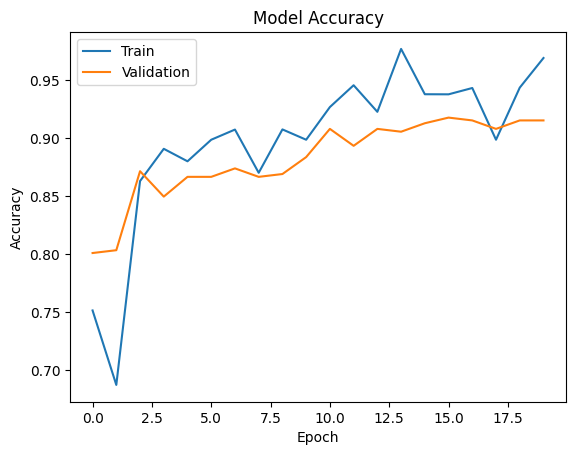

In [38]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [39]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.950606  0.950606   0.950606  0.950606


104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step


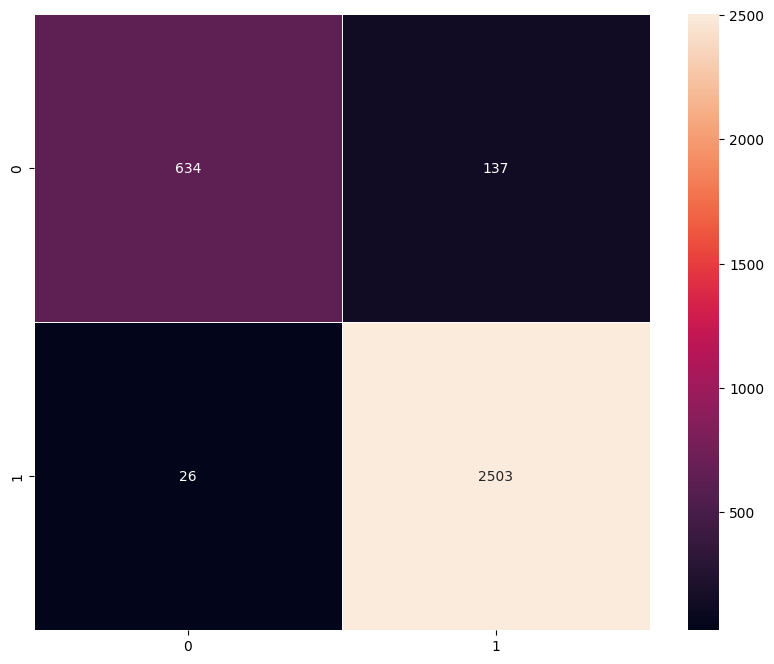

In [40]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [41]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.915049  0.915049   0.915049  0.915049


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step


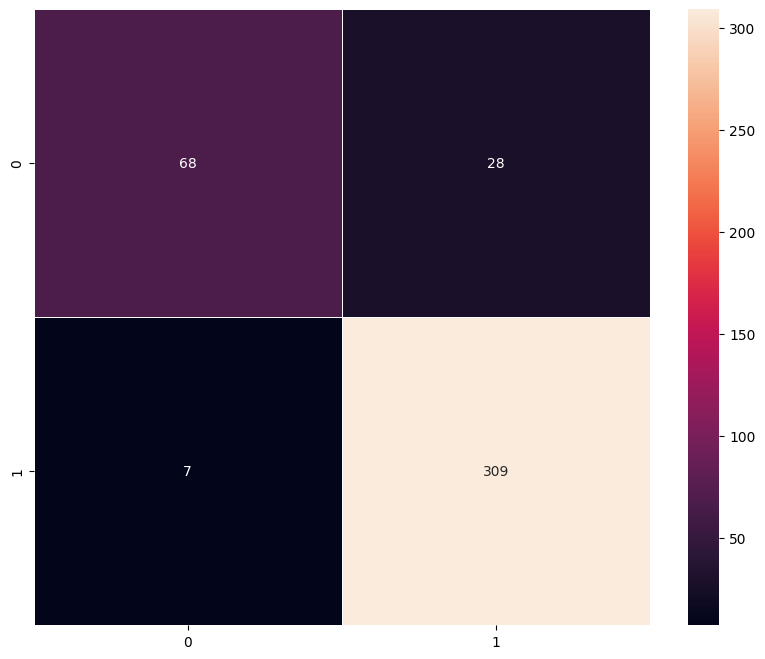

In [42]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

### Visualizing the predictions

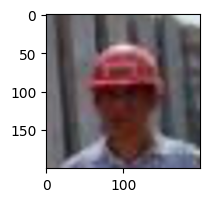

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted Label: 1
True Label: label    1
Name: 4098, dtype: int64


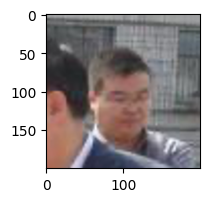

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Label: 1
True Label: label    0
Name: 719, dtype: int64


In [43]:
# For index 67
plt.figure(figsize=(2,2))
plt.imshow(X_val[67])
plt.show()
prediction = model_1.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[67]
print('True Label:', true_label)

# For index 76
plt.figure(figsize=(2,2))
plt.imshow(X_val[76])
plt.show()
prediction = model_1.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[76]
print('True Label:', true_label)

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





We will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten layer and a Feed Forward Neural Network.

In [45]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(model_VGG)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [46]:
# Compile model
model_2.compile(optimizer= 'adam', loss='binary_crossentropy', metrics=['accuracy'])

In [47]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [48]:
history_vgg16 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 750ms/step - accuracy: 0.7364 - loss: 0.6223 - val_accuracy: 0.8325 - val_loss: 0.4093
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8438 - loss: 0.4280 - val_accuracy: 0.8447 - val_loss: 0.3899
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 692ms/step - accuracy: 0.8380 - loss: 0.3546 - val_accuracy: 0.8762 - val_loss: 0.2890
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8828 - loss: 0.3045 - val_accuracy: 0.8738 - val_loss: 0.2875
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 687ms/step - accuracy: 0.8789 - loss: 0.2800 - val_accuracy: 0.9102 - val_loss: 0.2334
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9375 - loss: 0.1594 - val_accuracy: 0.9053 - val_loss: 0.2305
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 747ms/step - accuracy: 0.9009 - loss: 0.2271 - val_accuracy: 0.9078 - val_loss: 0.2207
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9100 - loss: 0.2261 - val_accuracy: 0.

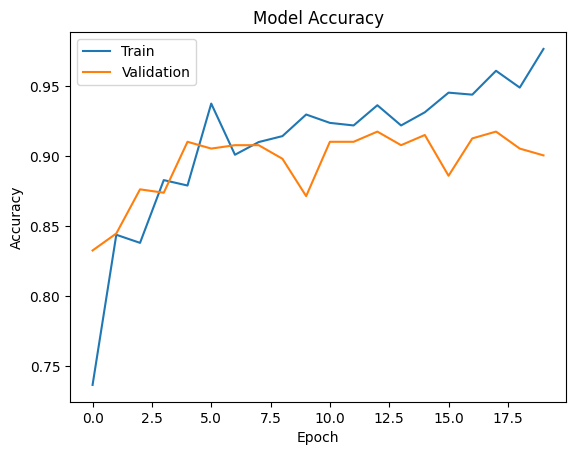

In [49]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [50]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.971818  0.971818   0.971818  0.971818


104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step


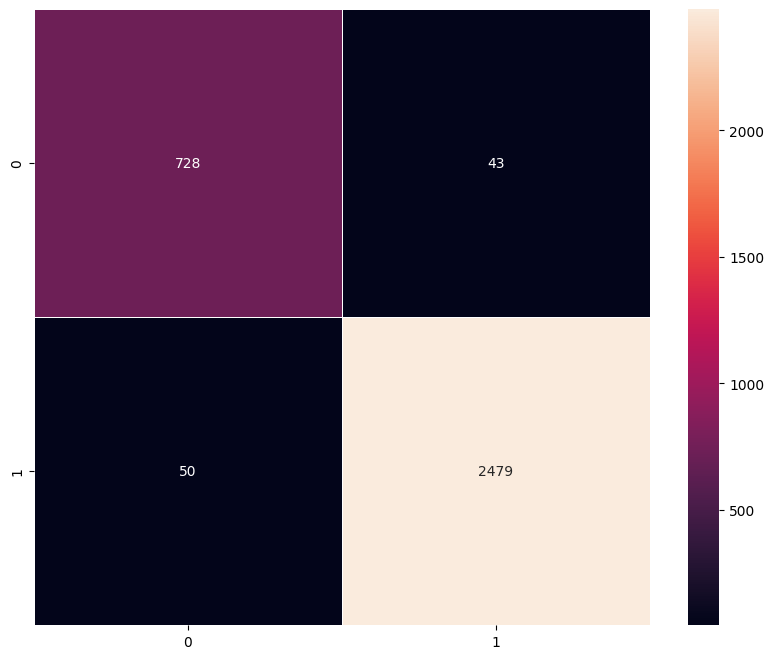

In [51]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [52]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.900485  0.900485   0.900485  0.900485


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step


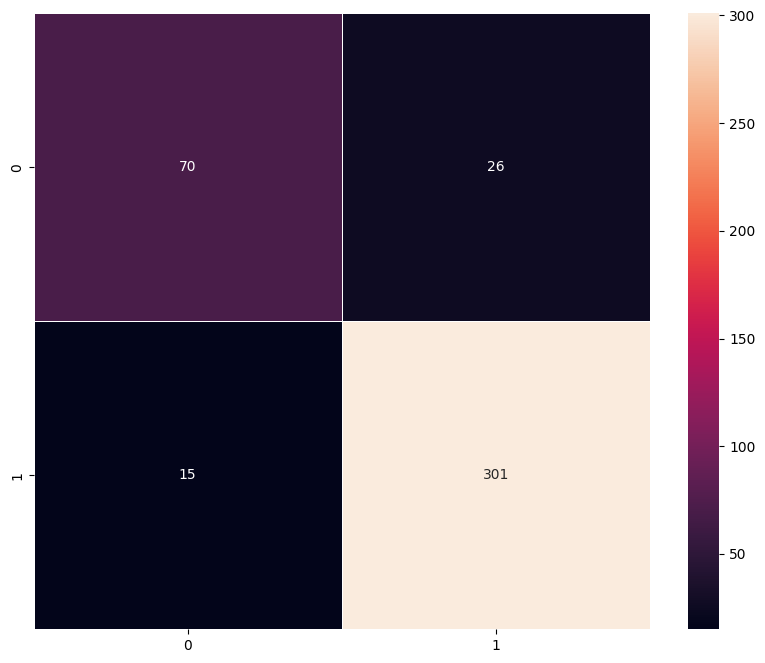

In [53]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

#### Visualizing the predictions

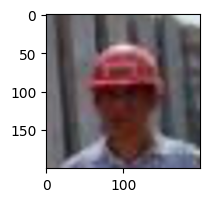

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Label: 1
True Label: label    1
Name: 4098, dtype: int64


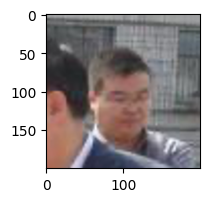

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Label: 1
True Label: label    0
Name: 719, dtype: int64


In [54]:
# For index 67
plt.figure(figsize=(2,2))
plt.imshow(X_val[67])
plt.show()
prediction = model_2.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[67]
print('True Label:', true_label)

# For index 76
plt.figure(figsize=(2,2))
plt.imshow(X_val[76])
plt.show()
prediction = model_2.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[76]
print('True Label:', true_label)

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [56]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(model_VGG)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [58]:
model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [59]:
model_3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [60]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              )

In [61]:
history_vgg16 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6592 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6484 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6538 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6875 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6579 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6406 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6668 - loss: 0.0000e+00 - val_accuracy: 0.7549 - val_loss: 0.0000e+00
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accura

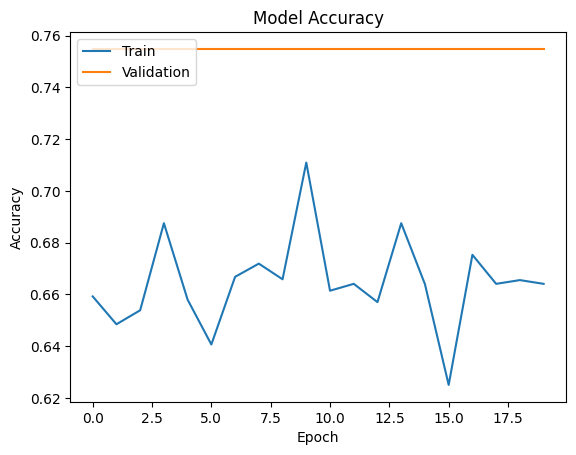

In [72]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [63]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.756667  0.756667   0.756667  0.756667


104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step


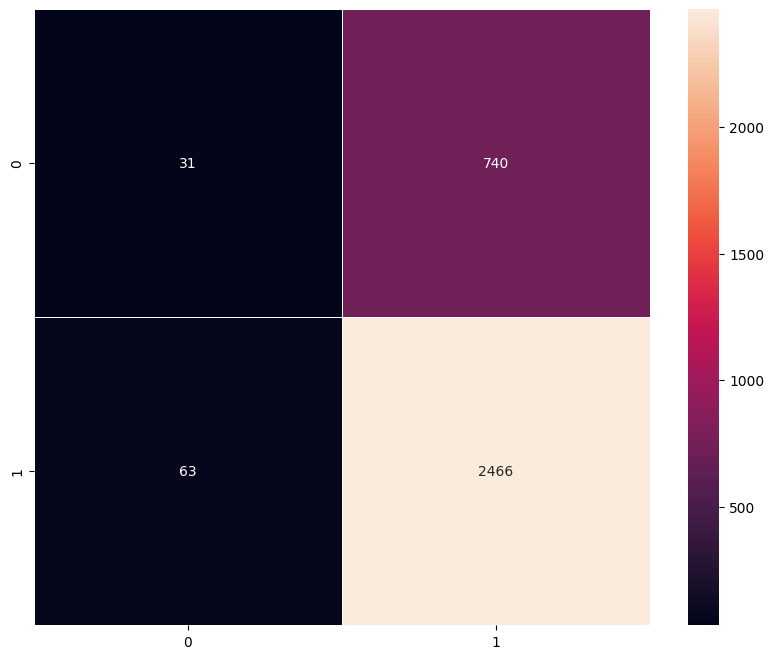

In [64]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [65]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.754854  0.754854   0.754854  0.754854


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


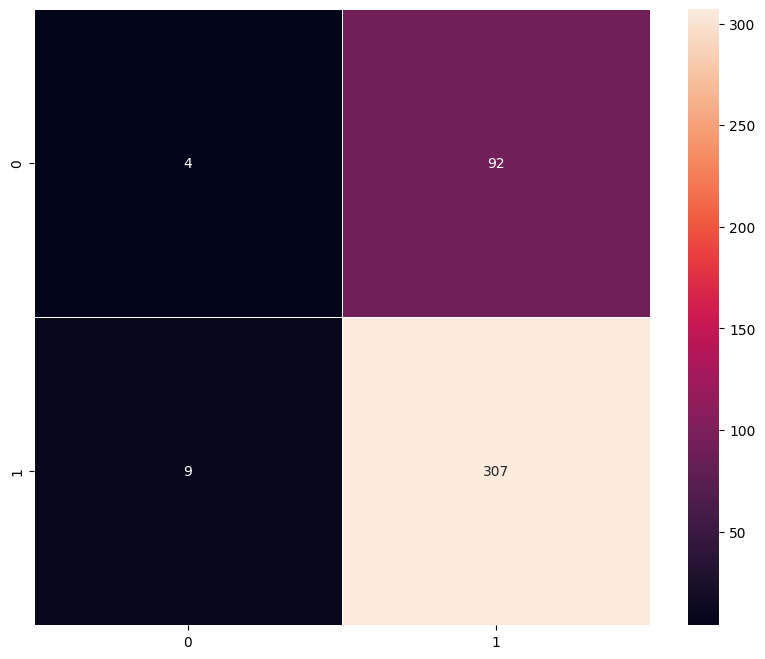

In [66]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

#### Visualizing the predictions

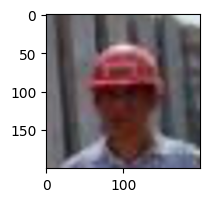

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Label: 1
True Label: label    1
Name: 4098, dtype: int64


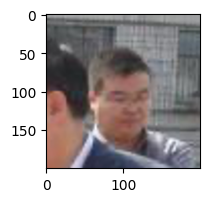

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Label: 1
True Label: label    0
Name: 719, dtype: int64


In [70]:
# For index 67
plt.figure(figsize=(2,2))
plt.imshow(X_val[67])
plt.show()
prediction = model_3.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[67]
print('True Label:', true_label)

# For index 76
plt.figure(figsize=(2,2))
plt.imshow(X_val[76])
plt.show()
prediction = model_3.predict(X_val_normalized[12].reshape(1, 200, 200, 3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[76]
print('True Label:', true_label)

# **Model Performance Comparison and Final Model Selection**

In [73]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_CNN_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Base CNN", "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [74]:
models_valid_comp_df = pd.concat(
    [
        model_CNN_valid_perf.T,
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Base CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [75]:
models_train_comp_df

,Base CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.960303,0.950606,0.971818,0.756667
Recall,0.960303,0.950606,0.971818,0.756667
Precision,0.960303,0.950606,0.971818,0.756667
F1 Score,0.960303,0.950606,0.971818,0.756667


In [76]:
models_valid_comp_df

,Base CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.929612,0.915049,0.900485,0.754854
Recall,0.929612,0.915049,0.900485,0.754854
Precision,0.929612,0.915049,0.900485,0.754854
F1 Score,0.929612,0.915049,0.900485,0.754854


In [77]:
models_train_comp_df - models_valid_comp_df

,Base CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.030691,0.035558,0.071333,0.001812
Recall,0.030691,0.035558,0.071333,0.001812
Precision,0.030691,0.035558,0.071333,0.001812
F1 Score,0.030691,0.035558,0.071333,0.001812


## Test Performance

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___